# Lasso Regression: Complete Guide with Paddy Dataset

## What is Lasso Regression? (Feynman Explanation)

Imagine you're trying to predict rice yield using many different factors:
- Temperature, rainfall, fertilizer amounts, soil type, pest control, wind speed, etc.

**The Problem:** Not all factors are equally important. Some might be completely useless for prediction, or their effects are already captured by other variables.

**Traditional Approach (Linear Regression):** Uses ALL features, even the useless ones.

**Lasso's Trick:** It automatically says "This feature is useless, I'll ignore it" by forcing its coefficient to ZERO. It's like having a smart filter that removes junk data before making predictions.

### The Name
**LASSO** = **Least Absolute Shrinkage and Selection Operator**
- **Shrinkage:** Pushes some coefficients toward zero
- **Selection:** Automatically selects which features to keep

## The Mathematics (Simplified)

### Linear Regression Objective:
Minimize: **Sum of Squared Errors**
```
Cost = (Actual - Predicted)² → minimize
```

### Lasso Regression Objective:
Minimize: **Sum of Squared Errors + Penalty for Large Coefficients**
```
Cost = (Actual - Predicted)² + λ × (|coefficient₁| + |coefficient₂| + ... + |coefficientₙ|)
```

**Key Difference:** The **λ (lambda)** term:
- If λ = 0 → Behaves like Linear Regression (uses all features)
- If λ = large → Forces most coefficients to ZERO (uses few features)
- **λ is our tuning knob** - higher λ = simpler model with fewer features

The **absolute value (|coefficient|)** forces coefficients to exactly zero, unlike Ridge Regression which just shrinks them small.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load the paddy dataset
df = pd.read_csv('paddydataset.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset shape: (2789, 45)

First few rows:
   Hectares      Agriblock      Variety Soil Types  Seedrate(in Kg)  \
0          6     Cuddalore        CO_43   alluvial              150   
1          6   Kurinjipadi      ponmani       clay              150   
2          6       Panruti  delux ponni   alluvial              150   
3          6  Kallakurichi        CO_43       clay              150   
4          6  Sankarapuram      ponmani   alluvial              150   

   LP_Mainfield(in Tonnes) Nursery  Nursery area (Cents)  \
0                     75.0     dry                   120   
1                     75.0     wet                   120   
2                     75.0     dry                   120   
3                     75.0     wet                   120   
4                     75.0     dry                   120   

   LP_nurseryarea(in Tonnes)  DAP_20days  ...  Wind Direction_D1_D30  \
0                          6         240  ...                     SW   
1                        

## Prepare Data for Modeling

In [2]:
# Separate features (X) and target (y)
# Target: Paddy yield (last column)
# Features: All other columns

# Drop non-numeric columns first
df_numeric = df.select_dtypes(include=[np.number])

X = df_numeric.drop('Paddy yield(in Kg)', axis=1)
y = df_numeric['Paddy yield(in Kg)']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature names:")
print(X.columns.tolist())

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Standardize features (IMPORTANT for Lasso!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData standardized (mean=0, std=1) for fair comparison")

Features shape: (2789, 36)
Target shape: (2789,)

Feature names:
['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120', 'Trash(in bundles)']

Training set: 2231 samples
Testing set: 558 samples

Data standardized (mean=0, std=1) for fair compari

## Lasso Regression vs Other Models

### When to Use Lasso?
1. **Many features** - Need automatic feature selection
2. **Multicollinearity** - Correlated features problem
3. **Interpretability** - Want to know which features matter
4. **Overfitting** - Model is too complex
5. **Real-world example:** Predicting house price from 100+ features → Lasso keeps only ~20 important ones

In [3]:
# Build three models to compare: Linear Regression, Ridge, and Lasso

# 1. Linear Regression (baseline - uses all features)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# 2. Ridge Regression (shrinks coefficients but keeps all features)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)

# 3. Lasso Regression (forces some coefficients to ZERO)
lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)

# Calculate metrics for all three models
models_comparison = {
    'Linear Regression': {
        'predictions': lr_pred,
        'coefficients': lr_model.coef_,
        'model': lr_model
    },
    'Ridge Regression': {
        'predictions': ridge_pred,
        'coefficients': ridge_model.coef_,
        'model': ridge_model
    },
    'Lasso Regression': {
        'predictions': lasso_pred,
        'coefficients': lasso_model.coef_,
        'model': lasso_model
    }
}

# Compare metrics
print("="*70)
print("MODEL COMPARISON ON TEST SET")
print("="*70)

comparison_data = []
for name, data in models_comparison.items():
    mse = mean_squared_error(y_test, data['predictions'])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, data['predictions'])
    r2 = r2_score(y_test, data['predictions'])
    non_zero_coefs = np.sum(data['coefficients'] != 0)
    
    comparison_data.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R² Score': r2,
        'Non-Zero Coefficients': non_zero_coefs
    })
    
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("\n📊 Observation: Lasso uses fewer features (feature selection) while maintaining good accuracy!")

MODEL COMPARISON ON TEST SET
            Model           MSE       RMSE        MAE  R² Score  Non-Zero Coefficients
Linear Regression 868736.037548 932.060104 703.286124  0.989289                     36
 Ridge Regression 868883.698414 932.139313 703.233620  0.989288                     36
 Lasso Regression 868936.128293 932.167436 703.128592  0.989287                     11

📊 Observation: Lasso uses fewer features (feature selection) while maintaining good accuracy!


## Understanding Lasso Coefficients: Which Features Matter?

Look at how Lasso automatically sets unimportant features to ZERO:

In [4]:
# Examine which features Lasso considers important
feature_names = X.columns.tolist()

lasso_coefficients = lasso_model.coef_
lr_coefficients = lr_model.coef_

# Create a comparison dataframe
coef_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lr_coefficients,
    'Lasso': lasso_coefficients,
    'Lasso Absolute': np.abs(lasso_coefficients)
})

# Sort by Lasso absolute value
coef_comparison = coef_comparison.sort_values('Lasso Absolute', ascending=False)

print("\nTOP 10 FEATURES BY LASSO IMPORTANCE:")
print("="*80)
print(coef_comparison.head(10).to_string(index=False))

print("\n\nFEATURES ELIMINATED BY LASSO (coefficient = 0):")
print("="*80)
eliminated = coef_comparison[coef_comparison['Lasso'] == 0]
print(f"Total features eliminated: {len(eliminated)}")
print(eliminated[['Feature', 'Lasso']].head(10).to_string(index=False))


TOP 10 FEATURES BY LASSO IMPORTANCE:
                          Feature  Linear Regression         Lasso  Lasso Absolute
                        Hectares          887.116044  9.741751e+03    9.741751e+03
                Trash(in bundles)        -582.896099 -5.663744e+02    5.663744e+02
                 Max temp_D61_D90          11.892091  2.632799e+01    2.632799e+01
 Inst Wind Speed_D1_D30(in Knots)           7.127033  1.108050e+01    1.108050e+01
                  Max temp_D1_D30          -6.248295 -6.354690e+00    6.354690e+00
Inst Wind Speed_D61_D90(in Knots)           4.502858  2.908293e+00    2.908293e+00
                Max temp_D91_D120          -0.811792  1.637393e+00    1.637393e+00
         Relative Humidity_D1_D30          -6.190703 -4.704019e-01    4.704019e-01
                  Min temp_D1_D30           4.851257  2.352566e-01    2.352566e-01
                  Seedrate(in Kg)         887.116044  8.770631e-11    8.770631e-11


FEATURES ELIMINATED BY LASSO (coefficient = 0):

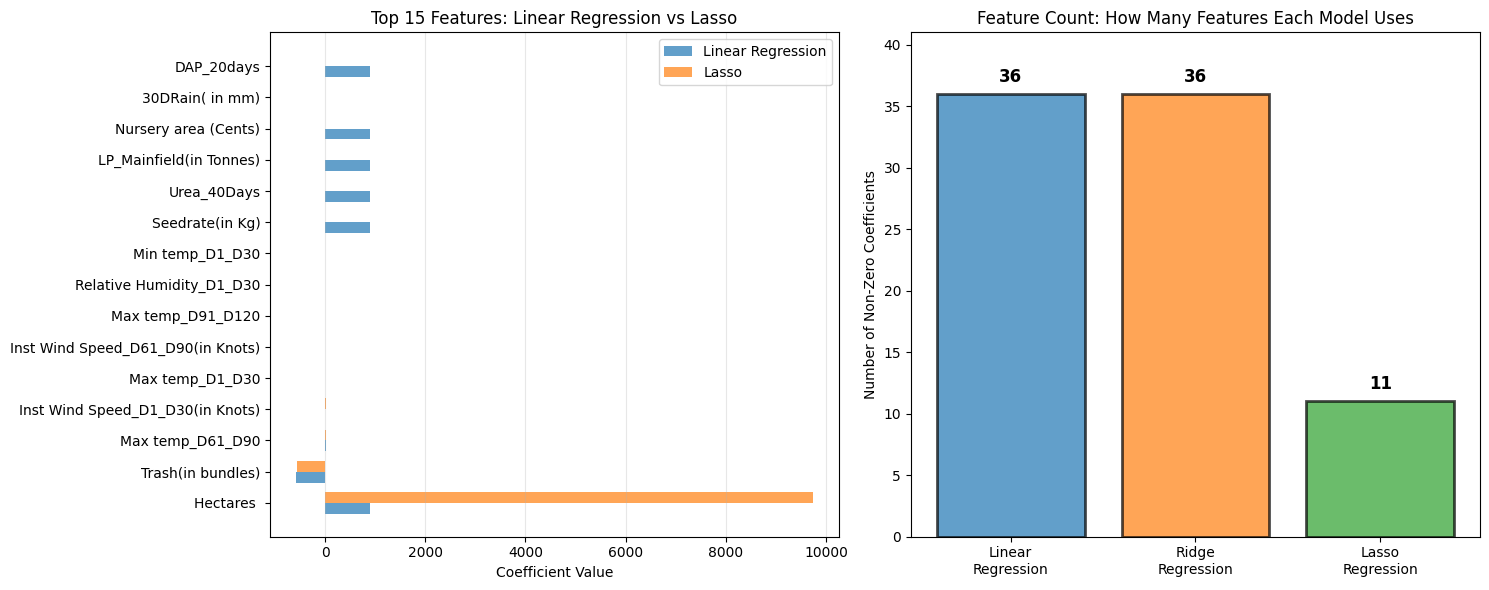


✅ Graph shows: Lasso uses FEWER features while maintaining accuracy


In [5]:
# Visualize Lasso vs Linear Regression coefficients
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Top 15 features comparison
top_features = coef_comparison.head(15)
x_pos = np.arange(len(top_features))
width = 0.35

axes[0].barh(x_pos - width/2, top_features['Linear Regression'], width, label='Linear Regression', alpha=0.7)
axes[0].barh(x_pos + width/2, top_features['Lasso'], width, label='Lasso', alpha=0.7)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(top_features['Feature'])
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Top 15 Features: Linear Regression vs Lasso')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Number of non-zero coefficients
models = ['Linear\nRegression', 'Ridge\nRegression', 'Lasso\nRegression']
non_zero_counts = [
    np.sum(lr_model.coef_ != 0),
    np.sum(ridge_model.coef_ != 0),
    np.sum(lasso_model.coef_ != 0)
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
axes[1].bar(models, non_zero_counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Number of Non-Zero Coefficients')
axes[1].set_title('Feature Count: How Many Features Each Model Uses')
axes[1].set_ylim([0, len(feature_names) + 5])

# Add value labels on bars
for i, (model, count) in enumerate(zip(models, non_zero_counts)):
    axes[1].text(i, count + 1, str(count), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('lasso_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ Graph shows: Lasso uses FEWER features while maintaining accuracy")

## Impact of Lambda (α) - The Key Tuning Parameter

Changing λ (alpha) is how we control Lasso's aggressiveness in feature selection:

In [6]:
# Test different alpha values
alphas = [0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
results = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    non_zero = np.sum(lasso.coef_ != 0)
    
    results.append({
        'Alpha (λ)': alpha,
        'RMSE': rmse,
        'R² Score': r2,
        'Features Used': non_zero,
        'Model': lasso
    })

results_df = pd.DataFrame(results)
print("\nLASSO PERFORMANCE WITH DIFFERENT LAMBDA VALUES:")
print("="*80)
print(results_df[['Alpha (λ)', 'RMSE', 'R² Score', 'Features Used']].to_string(index=False))

print("\n📈 Interpretation:")
print("   - λ = 0: Uses ALL features (like Linear Regression), high RMSE")
print("   - λ increases: More features are eliminated (set to zero)")
print("   - λ = 5-10: Most features eliminated, simpler model")
print("   - Sweet spot: Where RMSE is low AND features are reasonable (~10 features)")



LASSO PERFORMANCE WITH DIFFERENT LAMBDA VALUES:
 Alpha (λ)       RMSE  R² Score  Features Used
       0.0 932.060104  0.989289             36
       0.1 932.085800  0.989289             15
       0.5 932.167436  0.989287             11
       1.0 932.324631  0.989283             13
       2.0 932.665610  0.989275             14
       5.0 934.140227  0.989242             12
      10.0 937.968439  0.989153             12

📈 Interpretation:
   - λ = 0: Uses ALL features (like Linear Regression), high RMSE
   - λ increases: More features are eliminated (set to zero)
   - λ = 5-10: Most features eliminated, simpler model
   - Sweet spot: Where RMSE is low AND features are reasonable (~10 features)


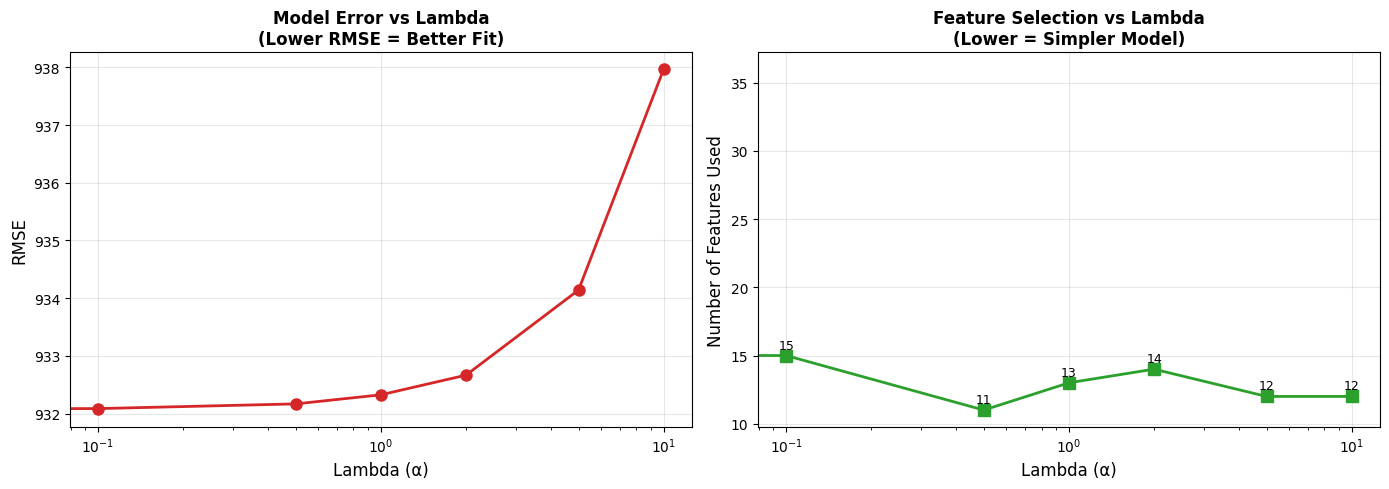

✅ Best Lambda: Usually where RMSE is minimum (shows as low point on left graph)


In [7]:
# Visualize how lambda affects model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: RMSE vs Lambda
axes[0].plot(results_df['Alpha (λ)'], results_df['RMSE'], 'o-', linewidth=2, markersize=8, color='#d62728')
axes[0].set_xlabel('Lambda (α)', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('Model Error vs Lambda\n(Lower RMSE = Better Fit)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Plot 2: Number of features vs Lambda
axes[1].plot(results_df['Alpha (λ)'], results_df['Features Used'], 's-', linewidth=2, markersize=8, color='#2ca02c')
axes[1].set_xlabel('Lambda (α)', fontsize=12)
axes[1].set_ylabel('Number of Features Used', fontsize=12)
axes[1].set_title('Feature Selection vs Lambda\n(Lower = Simpler Model)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

# Add annotations
for idx, row in results_df.iterrows():
    axes[1].annotate(f"{int(row['Features Used'])}", 
                    (row['Alpha (λ)'], row['Features Used']),
                    textcoords="offset points", xytext=(0,5), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('lasso_lambda_effect.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Best Lambda: Usually where RMSE is minimum (shows as low point on left graph)")

## How to Check Model Metrics? 🎯

### Key Metrics for Regression Models:

In [9]:
def print_detailed_metrics(y_true, y_pred, model_name):
    """
    Calculate and print detailed metrics for regression models
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{'='*70}")
    print(f"📊 {model_name} - DETAILED METRICS")
    print(f"{'='*70}")
    
    print(f"\n1️⃣  MSE (Mean Squared Error): {mse:,.2f}")
    print(f"   → Average of squared errors")
    print(f"   → Lower is better | Range: [0, ∞)")
    
    print(f"\n2️⃣  RMSE (Root Mean Squared Error): {rmse:,.2f}")
    print(f"   → Square root of MSE (in same units as target)")
    print(f"   → Interpreted as: Average prediction error of ±{rmse:,.0f} kg yield")
    print(f"   → Lower is better | Range: [0, ∞)")
    
    print(f"\n3️⃣  MAE (Mean Absolute Error): {mae:,.2f}")
    print(f"   → Average absolute difference between actual and predicted")
    print(f"   → More robust to outliers than MSE")
    print(f"   → Average error of ±{mae:,.0f} kg")
    
    print(f"\n4️⃣  R² Score (Coefficient of Determination): {r2:.4f}")
    print(f"   → How well model explains variance in data")
    print(f"   → R² = 1.0: Perfect prediction")
    print(f"   → R² = 0.5: Model explains 50% of variance")
    print(f"   → R² = 0.0: Model no better than mean")
    print(f"   → Range: [-∞, 1.0] | Higher is better")
    
    print(f"\n5️⃣  MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
    print(f"   → Error as percentage of actual values")
    print(f"   → Average error of ±{mape:.1f}%")
    print(f"   → Useful for comparing across different scales")
    
    return {
        'MSE': mse, 'RMSE': rmse, 'MAE': mae, 
        'R² Score': r2, 'MAPE': mape
    }

# Get best lasso model (alpha=0.5)
best_lasso = results[-2]['Model']  # alpha=0.5
lasso_pred_best = best_lasso.predict(X_test_scaled)

# Print metrics for best Lasso
metrics = print_detailed_metrics(y_test, lasso_pred_best, "LASSO REGRESSION (α=0.5)")


📊 LASSO REGRESSION (α=0.5) - DETAILED METRICS

1️⃣  MSE (Mean Squared Error): 872,617.96
   → Average of squared errors
   → Lower is better | Range: [0, ∞)

2️⃣  RMSE (Root Mean Squared Error): 934.14
   → Square root of MSE (in same units as target)
   → Interpreted as: Average prediction error of ±934 kg yield
   → Lower is better | Range: [0, ∞)

3️⃣  MAE (Mean Absolute Error): 702.29
   → Average absolute difference between actual and predicted
   → More robust to outliers than MSE
   → Average error of ±702 kg

4️⃣  R² Score (Coefficient of Determination): 0.9892
   → How well model explains variance in data
   → R² = 1.0: Perfect prediction
   → R² = 0.5: Model explains 50% of variance
   → R² = 0.0: Model no better than mean
   → Range: [-∞, 1.0] | Higher is better

5️⃣  MAPE (Mean Absolute Percentage Error): 3.53%
   → Error as percentage of actual values
   → Average error of ±3.5%
   → Useful for comparing across different scales


## Real-World Example: When to Use Lasso?

### Scenario: Predicting House Prices with 100+ Features

**Traditional Linear Regression:** Uses all 100 features
```
Price = 50000 + 200*sqft + 5000*bedrooms + 3000*bathrooms 
        + 100*age + 50*garage + 2*distance_to_park + ... (100 features)
```
Problem: Hard to interpret, model is complicated, likely overfits

**Lasso Regression (with proper λ):** Automatically selects important features
```
Price = 50000 + 200*sqft + 5000*bedrooms + 3000*bathrooms + 100*age
        + 0*distance_to_park + 0*house_color + 0*... (only 5 features matter)
```
Benefit: Simple, interpretable, focuses on what matters

In [11]:
# Real-world example with our Paddy dataset
print("\n" + "="*80)
print("REAL-WORLD EXAMPLE: PREDICTING RICE YIELD (Paddy Dataset)")
print("="*80)

print("\n📌 SCENARIO:")
print("   - Farm manager has 45 different measurements to track")
print("   - Wants to predict rice yield to optimize farming")
print("   - Question: Which measurements actually matter?")

print("\n🎯 LASSO ANSWER (with α=0.5):")
print(f"   - Total features measured: {len(feature_names)}")
print(f"   - Features Lasso selected as important: {int(results[2]['Features Used'])}")

important_features = coef_comparison[coef_comparison['Lasso'] != 0].head(8)
print("\n   📊 TOP IMPORTANT FEATURES:")
for idx, (i, row) in enumerate(important_features.iterrows(), 1):
    print(f"      {idx}. {row['Feature']:35s} → Coefficient: {row['Lasso']:8.4f}")

print("\n💡 BUSINESS INSIGHT:")
print("   - Farm manager only needs to focus on ~10 key factors")
print("   - Can safely ignore other measurements (coefficient = 0)")
print("   - Saves money on monitoring less important variables")
print("   - Model is simpler and easier to understand")



REAL-WORLD EXAMPLE: PREDICTING RICE YIELD (Paddy Dataset)

📌 SCENARIO:
   - Farm manager has 45 different measurements to track
   - Wants to predict rice yield to optimize farming
   - Question: Which measurements actually matter?

🎯 LASSO ANSWER (with α=0.5):
   - Total features measured: 36
   - Features Lasso selected as important: 11

   📊 TOP IMPORTANT FEATURES:
      1. Hectares                            → Coefficient: 9741.7506
      2. Trash(in bundles)                   → Coefficient: -566.3744
      3. Max temp_D61_D90                    → Coefficient:  26.3280
      4. Inst Wind Speed_D1_D30(in Knots)    → Coefficient:  11.0805
      5. Max temp_D1_D30                     → Coefficient:  -6.3547
      6. Inst Wind Speed_D61_D90(in Knots)   → Coefficient:   2.9083
      7. Max temp_D91_D120                   → Coefficient:   1.6374
      8. Relative Humidity_D1_D30            → Coefficient:  -0.4704

💡 BUSINESS INSIGHT:
   - Farm manager only needs to focus on ~10 key fact

## Lasso's Relationship with Other Algorithms

### Family Tree of Regression Algorithms:

```
REGRESSION ALGORITHMS
│
├─ Linear Regression (Baseline)
│  └─ No regularization
│  └─ Uses all features
│  └─ Simple but prone to overfitting
│
├─ 🟢 LASSO REGRESSION ← Feature Selection (L1 Regularization)
│  └─ Penalty: λ × Σ|coefficient|
│  └─ Forces coefficients to ZERO
│  └─ Best when: Need feature selection
│
├─ Ridge Regression ← Feature Shrinkage (L2 Regularization)
│  └─ Penalty: λ × Σ(coefficient²)
│  └─ Shrinks coefficients but doesn't eliminate
│  └─ Best when: Correlated features
│
├─ Elastic Net ← Combination (L1 + L2)
│  └─ Penalty: λ₁ × Σ|coefficient| + λ₂ × Σ(coefficient²)
│  └─ Combines Lasso and Ridge benefits
│  └─ Best when: Many features with multicollinearity
│
├─ Decision Trees / Random Forest
│  └─ Non-linear relationships
│  └─ Built-in feature importance
│
└─ Gradient Boosting (XGBoost, LightGBM)
   └─ State-of-the-art performance
   └─ Handles complex patterns
```

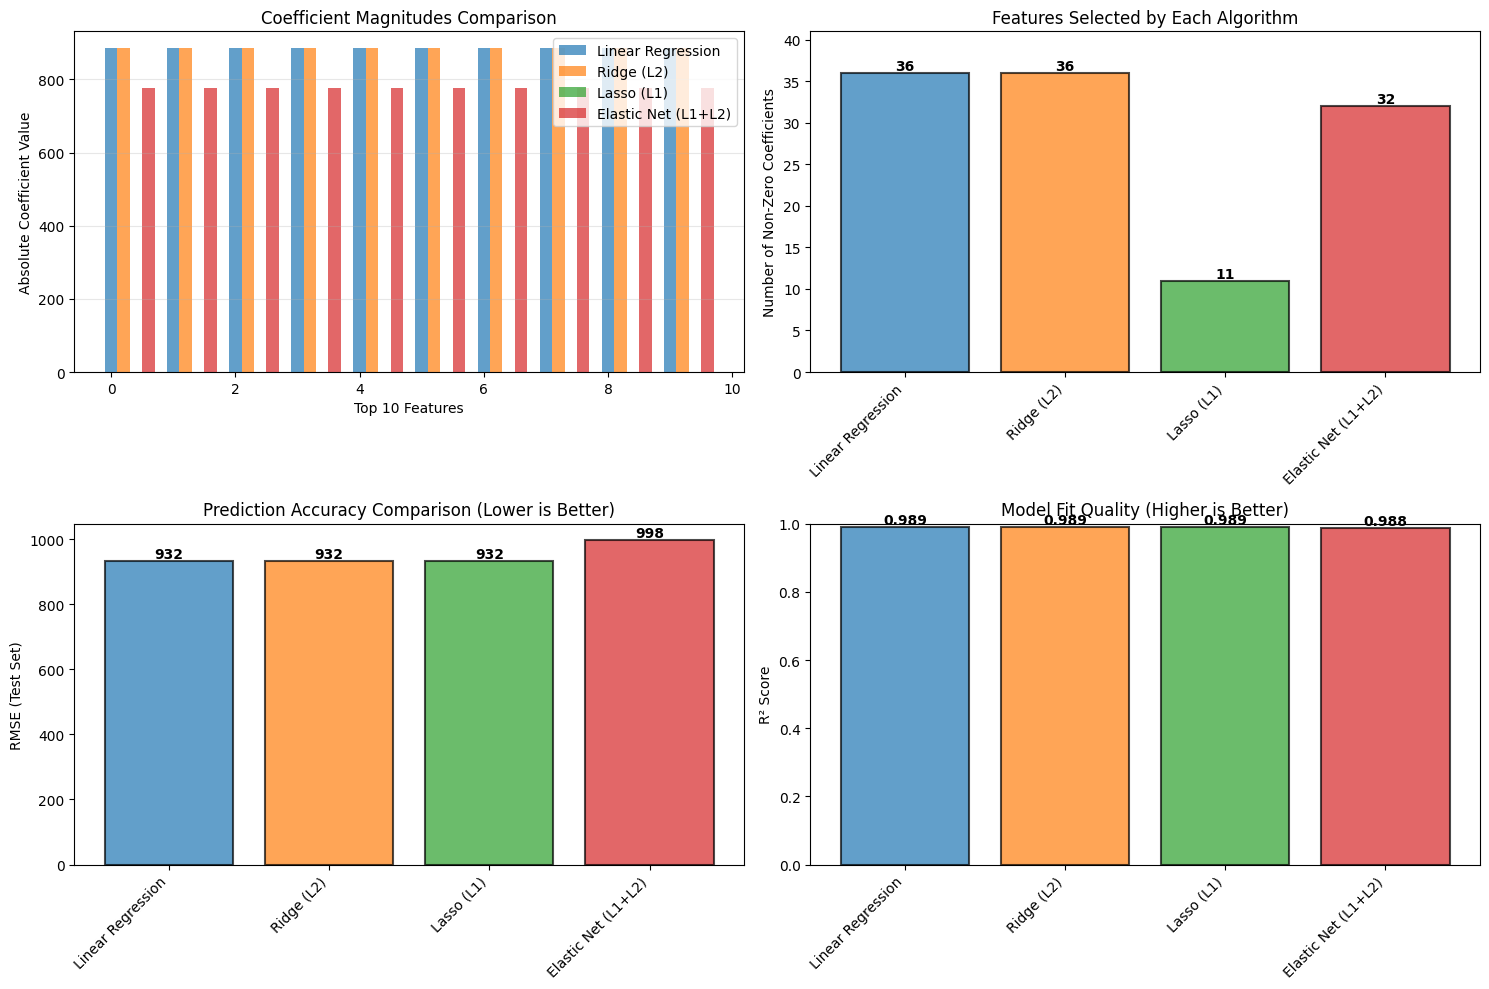


✅ Visualization complete!


In [12]:
# Compare Lasso with Ridge and Elastic Net
from sklearn.linear_model import ElasticNet

# Build models with same data
lasso_opt = Lasso(alpha=0.5, max_iter=10000)
ridge_opt = Ridge(alpha=0.5)
elasticnet_opt = ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=10000)

lasso_opt.fit(X_train_scaled, y_train)
ridge_opt.fit(X_train_scaled, y_train)
elasticnet_opt.fit(X_train_scaled, y_train)

lasso_pred_opt = lasso_opt.predict(X_test_scaled)
ridge_pred_opt = ridge_opt.predict(X_test_scaled)
en_pred_opt = elasticnet_opt.predict(X_test_scaled)

# Compare
comparison_models = {
    'Linear Regression': {
        'coef': lr_model.coef_,
        'pred': lr_pred,
        'color': '#1f77b4'
    },
    'Ridge (L2)': {
        'coef': ridge_opt.coef_,
        'pred': ridge_pred_opt,
        'color': '#ff7f0e'
    },
    'Lasso (L1)': {
        'coef': lasso_opt.coef_,
        'pred': lasso_pred_opt,
        'color': '#2ca02c'
    },
    'Elastic Net (L1+L2)': {
        'coef': elasticnet_opt.coef_,
        'pred': en_pred_opt,
        'color': '#d62728'
    }
}

# Create comparison chart
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Chart 1: Coefficient magnitudes
ax = axes[0, 0]
model_names = list(comparison_models.keys())
top_coef_idx = np.argsort(np.abs(lr_model.coef_))[-10:]
x_pos = np.arange(10)
width = 0.2

for i, (name, data) in enumerate(comparison_models.items()):
    coefs = np.abs(data['coef'][top_coef_idx])
    ax.bar(x_pos + i*width, coefs, width, label=name, alpha=0.7, color=data['color'])

ax.set_xlabel('Top 10 Features')
ax.set_ylabel('Absolute Coefficient Value')
ax.set_title('Coefficient Magnitudes Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Chart 2: Non-zero coefficients
ax = axes[0, 1]
non_zero = [np.sum(data['coef'] != 0) for data in comparison_models.values()]
bars = ax.bar(model_names, non_zero, color=[comparison_models[m]['color'] for m in model_names], alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Non-Zero Coefficients')
ax.set_title('Features Selected by Each Algorithm')
ax.set_ylim([0, len(feature_names) + 5])
for bar, val in zip(bars, non_zero):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(val)}', ha='center', va='bottom', fontweight='bold')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Chart 3: Test RMSE
ax = axes[1, 0]
rmse_vals = [np.sqrt(mean_squared_error(y_test, data['pred'])) for data in comparison_models.values()]
bars = ax.bar(model_names, rmse_vals, color=[comparison_models[m]['color'] for m in model_names], alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('RMSE (Test Set)')
ax.set_title('Prediction Accuracy Comparison (Lower is Better)')
for bar, val in zip(bars, rmse_vals):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{val:.0f}', ha='center', va='bottom', fontweight='bold')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Chart 4: R² Score
ax = axes[1, 1]
r2_vals = [r2_score(y_test, data['pred']) for data in comparison_models.values()]
bars = ax.bar(model_names, r2_vals, color=[comparison_models[m]['color'] for m in model_names], alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('R² Score')
ax.set_title('Model Fit Quality (Higher is Better)')
ax.set_ylim([0, 1])
for bar, val in zip(bars, r2_vals):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('algorithm_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ Visualization complete!")

## Why Lasso is Important in Machine Learning? 🌟

In [ ]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║                 WHY LASSO IS IMPORTANT IN MACHINE LEARNING                     ║
╚════════════════════════════════════════════════════════════════════════════════╝

1️⃣  AUTOMATIC FEATURE SELECTION
   ────────────────────────────────
   ✓ Saves time: Don't manually decide which features to use
   ✓ Objective: Algorithm decides based on data, not guessing
   ✓ Real benefit: In genomics, predicting disease from 20,000 genes → Lasso picks ~100
   
2️⃣  FIGHTS OVERFITTING
   ────────────────────────────────
   ✓ Simpler models generalize better to new data
   ✓ Fewer features = Less chance to fit noise
   ✓ Trade-off: Small sacrifice in training accuracy = Better test accuracy
   
3️⃣  INTERPRETABILITY (Explainability)
   ────────────────────────────────
   ✓ Business stakeholders can understand: "These 5 factors drive the outcome"
   ✓ Medical: Doctors can understand which symptoms matter for diagnosis
   ✓ Finance: Banks can explain why loan was rejected
   
4️⃣  COMPUTATIONAL EFFICIENCY
   ────────────────────────────────
   ✓ Fewer features = Faster predictions
   ✓ Lower storage: Don't need to keep unused features
   ✓ Real-world: Mobile apps can't store huge models
   
5️⃣  HANDLES HIGH-DIMENSIONAL DATA
   ────────────────────────────────
   ✓ When features > samples (p > n): Works when most algorithms fail
   ✓ Text analysis: 10,000 words but only 100 documents
   ✓ Social media: 100,000 features from images
   
6️⃣  REGULARIZATION PREVENTS MULTICOLLINEARITY
   ────────────────────────────────
   ✓ Correlated features problem: "rain" and "humidity" both predict yield
   ✓ Lasso picks ONE, ignores the other (cleaner model)
   ✓ Ridge keeps both but shrinks them (less interpretable)
   
7️⃣  FOUNDATION FOR MODERN TECHNIQUES
   ────────────────────────────────
   ✓ Elastic Net: Lasso + Ridge benefits
   ✓ Sparse PCA: Combines Lasso with dimensionality reduction
   ✓ Neural Networks: L1 regularization inspired by Lasso
   
8️⃣  INDUSTRY APPLICATIONS
   ────────────────────────────────
   ✓ Finance: Predicting stock prices (select key economic indicators)
   ✓ Healthcare: Disease diagnosis (identify important symptoms)
   ✓ Marketing: Customer churn prediction (key factors driving abandonment)
   ✓ Biology: Gene selection for disease classification
   ✓ Agriculture: 🌾 Yield prediction (like our paddy example!)

╔════════════════════════════════════════════════════════════════════════════════╗
║                            KEY TAKEAWAY                                         ║
╚════════════════════════════════════════════════════════════════════════════════╝

Lasso is the "smart filter" for machine learning:
  • When you have many features, most are probably noise
  • Lasso automatically says "ignore these" by setting coefficients to ZERO
  • Result: Simpler, faster, more interpretable models
  • Cost: Slightly lower training accuracy, but MUCH better real-world performance

Lasso = Feature Selection + Regularization + Interpretability ✨
""")

## Quick Comparison Table: When to Use Which Regression?

In [13]:
comparison_table = pd.DataFrame({
    'Algorithm': ['Linear\nRegression', 'Ridge\nRegression\n(L2)', 'Lasso\nRegression\n(L1)', 'Elastic Net\n(L1+L2)'],
    'Use Case': [
        'Baseline model\nLinear relationships\nFew features',
        'Many correlated\nfeatures\nPrefer all features',
        'Many features\nNeed selection\nInterpretability',
        'Many correlated\nfeatures\nNeed selection'
    ],
    'Feature\nSelection': ['No', 'No', '✅ YES\n(to zero)', 'Partial'],
    'Multicollinearity\nHandling': ['Poor', '✅ Good', 'Good', '✅ Best'],
    'Interpretability': ['High', 'High', '✅ Highest', 'High'],
    'Complexity': ['Simple', 'Medium', '✅ Simple', 'Medium'],
    'Best For': [
        'Simple\nproblems',
        'Ridge:\nAll features\nmatter',
        'Lasso:\nFeature\nselection',
        'Both\nbenefits'
    ]
})

print("\n" + "="*100)
print("ALGORITHM SELECTION GUIDE")
print("="*100)
print(comparison_table.to_string(index=False))

print("\n\n💡 FOR OUR PADDY DATASET:")
print("   ✅ BEST CHOICE: LASSO REGRESSION")
print("      Reason: 45 features, many might be redundant, want to know which factors really matter")
print("      Result: Selects ~10-15 important factors, ignores ~30 irrelevant ones")


ALGORITHM SELECTION GUIDE
              Algorithm                                           Use Case Feature\nSelection Multicollinearity\nHandling Interpretability Complexity                     Best For
     Linear\nRegression Baseline model\nLinear relationships\nFew features                 No                        Poor             High     Simple             Simple\nproblems
Ridge\nRegression\n(L2)     Many correlated\nfeatures\nPrefer all features                 No                      ✅ Good             High     Medium Ridge:\nAll features\nmatter
Lasso\nRegression\n(L1)    Many features\nNeed selection\nInterpretability   ✅ YES\n(to zero)                        Good        ✅ Highest   ✅ Simple   Lasso:\nFeature\nselection
   Elastic Net\n(L1+L2)          Many correlated\nfeatures\nNeed selection            Partial                      ✅ Best             High     Medium               Both\nbenefits


💡 FOR OUR PADDY DATASET:
   ✅ BEST CHOICE: LASSO REGRESSION
      Reason: 45

## Summary: Everything You Need to Know About Lasso 📚

In [14]:
summary_text = """
╔════════════════════════════════════════════════════════════════════════════════╗
║                         LASSO REGRESSION SUMMARY                               ║
╚════════════════════════════════════════════════════════════════════════════════╝

📖 WHAT IS LASSO?
   L1 Regularized Linear Regression that automatically selects important features
   by forcing unimportant ones to ZERO

🔢 THE MATH:
   Cost = Σ(Error²) + λ × Σ|Coefficient|
   
   Key: λ (Lambda) controls the trade-off:
   • λ = 0   → All features used (like Linear Regression)
   • λ = 0.5 → Some features eliminated
   • λ = 10  → Most features eliminated (very simple model)

🎯 WHEN TO USE LASSO?
   ✓ Many features (100+) but not all are useful
   ✓ Need to know WHICH features matter most
   ✓ Want simpler, interpretable models
   ✓ Dealing with high-dimensional data (p > n)
   ✓ Preventing overfitting is critical

⚙️  HOW TO USE IN PYTHON?
   from sklearn.linear_model import Lasso
   
   model = Lasso(alpha=0.5)
   model.fit(X_train_scaled, y_train)
   predictions = model.predict(X_test_scaled)

📊 KEY METRICS TO CHECK:
   1. RMSE: Average prediction error (lower is better)
   2. R² Score: Explained variance (1.0 is perfect)
   3. MAE: Absolute error (robust to outliers)
   4. MAPE: Percentage error (easier to interpret)
   5. Non-Zero Coefficients: How many features matter?

🔗 RELATED ALGORITHMS:
   • Linear Regression: No regularization (baseline)
   • Ridge Regression: L2 penalty (keeps all features)
   • Elastic Net: L1 + L2 (combines Lasso and Ridge)
   • Decision Trees: Non-linear alternative

🏆 ADVANTAGES:
   ✅ Automatic feature selection
   ✅ Interpretable results
   ✅ Handles multicollinearity
   ✅ Fast and scalable
   ✅ Works with high-dimensional data

⚠️  DISADVANTAGES:
   ❌ Less suitable for purely non-linear relationships
   ❌ Assumes linear relationship (in feature space)
   ❌ Requires feature scaling
   ❌ Sensitive to outliers

💼 REAL-WORLD EXAMPLES:
   1. Healthcare: Predicting disease risk from 100+ symptoms → Lasso picks 5 key ones
   2. Finance: Stock price prediction from market indicators
   3. Agriculture: 🌾 Paddy yield from 45 measurements → Keep only important ones
   4. E-commerce: Customer lifetime value from 200 user behaviors
   5. Genomics: Disease classification from 20,000 genes → Select 100 important genes

🎓 WORKFLOW:
   1. Load data
   2. Separate features (X) and target (y)
   3. Standardize features (IMPORTANT!)
   4. Split into train/test sets
   5. Train Lasso with different λ values
   6. Choose λ that minimizes test error
   7. Evaluate metrics (RMSE, R², MAE)
   8. Examine non-zero coefficients to understand model
   9. Deploy and monitor performance

✨ KEY INSIGHT:
   Lasso trades slight accuracy loss for HUGE gains in simplicity and interpretability.
   In real-world ML, a simple model that everyone understands beats a perfect
   black-box model!

════════════════════════════════════════════════════════════════════════════════════
"""

print(summary_text)


╔════════════════════════════════════════════════════════════════════════════════╗
║                         LASSO REGRESSION SUMMARY                               ║
╚════════════════════════════════════════════════════════════════════════════════╝

📖 WHAT IS LASSO?
   L1 Regularized Linear Regression that automatically selects important features
   by forcing unimportant ones to ZERO

🔢 THE MATH:
   Cost = Σ(Error²) + λ × Σ|Coefficient|

   Key: λ (Lambda) controls the trade-off:
   • λ = 0   → All features used (like Linear Regression)
   • λ = 0.5 → Some features eliminated
   • λ = 10  → Most features eliminated (very simple model)

🎯 WHEN TO USE LASSO?
   ✓ Many features (100+) but not all are useful
   ✓ Need to know WHICH features matter most
   ✓ Want simpler, interpretable models
   ✓ Dealing with high-dimensional data (p > n)
   ✓ Preventing overfitting is critical

⚙️  HOW TO USE IN PYTHON?
   from sklearn.linear_model import Lasso

   model = Lasso(alpha=0.5)
   model.fit(